In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings as ws 
ws.filterwarnings('ignore')

In [37]:
df = pd.read_csv(r'C:\Users\BCS\Downloads\HR-attrition-project\project-3\HR Attrition Analysis Self.csv')
df.head(5)

,Unnamed: 0,EmployeeID,Age,JobRole,MonthlyIncome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,Education,DistanceFromHome,MaritalStatus,NumCompaniesWorked,OverTime,Attrition
0,0,1,50,Sales Executive,17422,3,3,4,12,College,34,Single,5,No,Yes
1,1,2,36,Research Director,11700,4,1,16,3,Master,3,Divorced,6,No,No
2,2,3,29,Laboratory Technician,7693,1,3,27,5,Doctor,8,Married,9,No,No
3,3,4,42,Research Scientist,2767,2,1,24,7,College,31,Divorced,1,Yes,No
4,4,5,40,Sales Executive,16818,1,4,28,12,Below College,11,Divorced,9,No,No


In [38]:
df.isnull().sum()

Unnamed: 0            0
EmployeeID            0
Age                   0
JobRole               0
MonthlyIncome         0
JobSatisfaction       0
WorkLifeBalance       0
YearsAtCompany        0
YearsInCurrentRole    0
Education             0
DistanceFromHome      0
MaritalStatus         0
NumCompaniesWorked    0
OverTime              0
Attrition             0
dtype: int64

In [40]:
df.drop('Unnamed: 0',axis='columns',inplace=True)

In [41]:
df.head(5)

,EmployeeID,Age,JobRole,MonthlyIncome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,Education,DistanceFromHome,MaritalStatus,NumCompaniesWorked,OverTime,Attrition
0,1,50,Sales Executive,17422,3,3,4,12,College,34,Single,5,No,Yes
1,2,36,Research Director,11700,4,1,16,3,Master,3,Divorced,6,No,No
2,3,29,Laboratory Technician,7693,1,3,27,5,Doctor,8,Married,9,No,No
3,4,42,Research Scientist,2767,2,1,24,7,College,31,Divorced,1,Yes,No
4,5,40,Sales Executive,16818,1,4,28,12,Below College,11,Divorced,9,No,No


In [42]:
#1. What are the key factors driving employee attrition?
from sklearn.preprocessing import LabelEncoder

le =  LabelEncoder()

df['Attrition'] = le.fit_transform(df['Attrition'])
df.head(5)

,EmployeeID,Age,JobRole,MonthlyIncome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,Education,DistanceFromHome,MaritalStatus,NumCompaniesWorked,OverTime,Attrition
0,1,50,Sales Executive,17422,3,3,4,12,College,34,Single,5,No,1
1,2,36,Research Director,11700,4,1,16,3,Master,3,Divorced,6,No,0
2,3,29,Laboratory Technician,7693,1,3,27,5,Doctor,8,Married,9,No,0
3,4,42,Research Scientist,2767,2,1,24,7,College,31,Divorced,1,Yes,0
4,5,40,Sales Executive,16818,1,4,28,12,Below College,11,Divorced,9,No,0


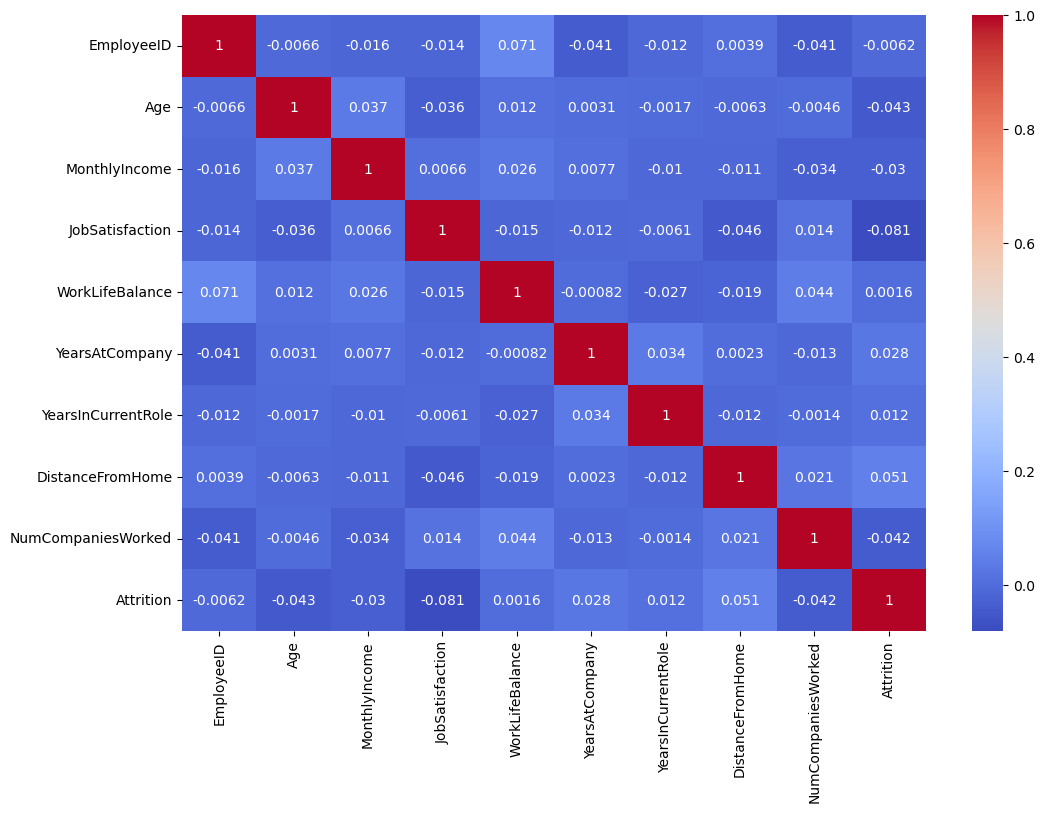

In [43]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [45]:
#2. Which job roles have the highest attrition rates?
# Analyze attrition by job role to help HR focus retention strategies on critical roles with high turnover.
Highest = df.groupby('JobRole')['Attrition'].mean()*100
print(Highest.sort_values(ascending=True))

JobRole
Manager                      17.592593
Human Resources              20.535714
Research Scientist           21.804511
Manufacturing Director       23.809524
Sales Representative         26.363636
Sales Executive              27.522936
Healthcare Representative    28.037383
Laboratory Technician        29.090909
Research Director            31.132075
Name: Attrition, dtype: float64


In [47]:
#3. How does employee satisfaction correlate with attrition?
# Explore how job satisfaction levels relate to attrition and if dissatisfaction predicts resignation.
df['JobSatisfaction'].corr(df['Attrition'])

np.float64(-0.08077063630275123)

In [52]:
#4. What is the impact of overtime on employee retention?
#Investigate if employees working overtime are more likely to quit and by how much.
df.groupby('OverTime')['Attrition'].mean()*100

OverTime
No     19.765739
Yes    36.277603
Name: Attrition, dtype: float64

In [53]:
#5. Does salary influence attrition?
#Analyze monthly income ranges and their corresponding attrition rates to see if pay is a factor.
df['MonthlyIncome'].corr(df['Attrition'])

np.float64(-0.030136260291833483)

In [60]:
#6. How does length of service affect attrition risk?
# Identify if newer employees leave more often than those with longer tenure.

df['Emp_Cat'] =  pd.cut(df['YearsAtCompany'],bins=[0,2,5,10,40],labels=['0-2 Years','3-5 Years','6-10 Years','10+ Years'])
print(df.groupby('Emp_Cat')['Attrition'].mean()*100)

Emp_Cat
0-2 Years     28.571429
3-5 Years     21.276596
6-10 Years    18.954248
10+ Years     26.179604
Name: Attrition, dtype: float64


In [65]:
#7. Are there demographic trends in attrition?
# Look at age, marital status, and distance from home to see if any demographic groups are more prone to resign.
df['Age_group'] = pd.cut(df['Age'],bins=[18,25,35,45,60],labels=['18-25','26-35','36-45','46-60'])
df['Distance_Group'] = pd.cut(df['DistanceFromHome'],bins=[0,5,10,20,50],labels=['0-5 KM','6-10 KM','11-20 KM','20+ KM'])
df.head(5)

,EmployeeID,Age,JobRole,MonthlyIncome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,Education,DistanceFromHome,MaritalStatus,NumCompaniesWorked,OverTime,Attrition,Emp_Cat,Age_group,Distance_Group
0,1,50,Sales Executive,17422,3,3,4,12,College,34,Single,5,No,1,3-5 Years,46-60,20+ KM
1,2,36,Research Director,11700,4,1,16,3,Master,3,Divorced,6,No,0,10+ Years,36-45,0-5 KM
2,3,29,Laboratory Technician,7693,1,3,27,5,Doctor,8,Married,9,No,0,10+ Years,26-35,6-10 KM
3,4,42,Research Scientist,2767,2,1,24,7,College,31,Divorced,1,Yes,0,10+ Years,36-45,20+ KM
4,5,40,Sales Executive,16818,1,4,28,12,Below College,11,Divorced,9,No,0,10+ Years,36-45,11-20 KM


In [66]:
print(df.groupby('Age_group')['Attrition'].mean()*100)
print(df.groupby('MaritalStatus')['Attrition'].mean()*100)
print(df.groupby('Distance_Group')['Attrition'].mean()*100)

Age_group
18-25    35.514019
26-35    23.505976
36-45    24.066390
46-60    23.690773
Name: Attrition, dtype: float64
MaritalStatus
Divorced    24.159021
Married     24.260355
Single      26.567164
Name: Attrition, dtype: float64
Distance_Group
0-5 KM      21.428571
6-10 KM     24.719101
11-20 KM    23.500000
20+ KM      26.210351
Name: Attrition, dtype: float64


In [68]:
#10. How can HR improve employee retention based on the data?
#Provide actionable recommendations (e.g., improve work-life balance, increase pay, reduce overtime).

17000